['Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor', 'I

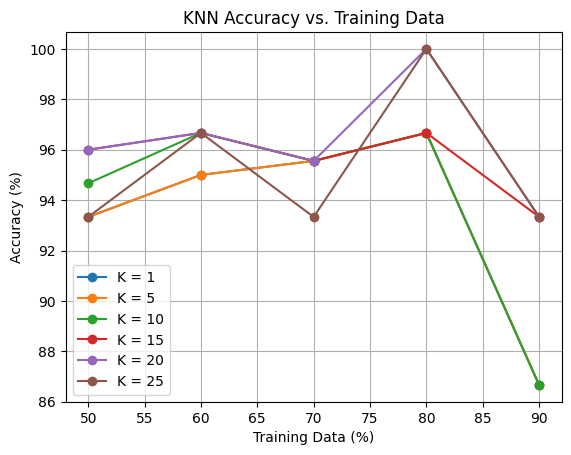

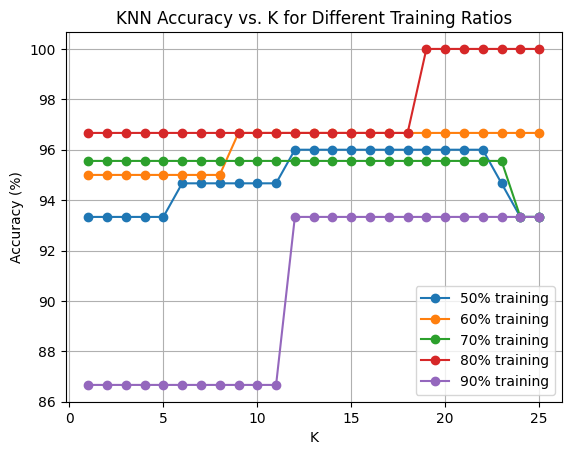

In [ ]:
import math
#import string
import numpy as np
import matplotlib.pyplot as plt

#data input as [[[values],[lables]],[[values1],[lables1]],...]
def KNN(data, pointToFind, k):
  #find Closests
  #closest[0] = dist, [1] = value, [2] = labels, [3] = weight
  
  Closest = {"Dist": [], "Value": [], "Labels": [], "Weight": []}
  for Point in data:
    dist = 0
    for variableId in range(len(Point[0])):
      dist += ((pointToFind[variableId]-Point[0][variableId])**2)
    dist = math.sqrt(dist)
    
    #add to Closest
    if len(Closest["Dist"]) >= k:
      compareItem = max(Closest["Dist"])
      if compareItem > dist:
        #get indexs and choose the first one
        index = Closest["Dist"].index(compareItem)
        Closest["Dist"][index] = dist
        Closest["Value"][index] = Point[0]
        Closest["Labels"][index] = Point[1]
        Closest["Weight"][index] = [0]
    else:
      Closest["Dist"].append(dist)
      Closest["Value"].append(Point[0])
      Closest["Labels"].append(Point[1])
      Closest["Weight"].append([0])

  #Value fix/weighting
  MinimumVal = min(Closest["Dist"])
  MaximumVal = max(Closest["Dist"])

  #Comparaisons[0] = labels, Comparaisons[1] = total weight
  Comparaisons = {"Labels": [], "Weights": []}
  for itemIndex in range(len(Closest["Dist"])):
    value = (Closest["Dist"][itemIndex] - MinimumVal)
    if (MaximumVal-MinimumVal) != 0:
      value = value/(MaximumVal-MinimumVal)
    value = 1 - value
    Closest["Weight"][itemIndex] = value
  
    if Closest["Labels"][itemIndex] not in Comparaisons["Labels"]:
      Comparaisons["Labels"].append(Closest["Labels"][itemIndex]) #WARNING: I don't know why but 0 works here. If there is more than one label per thing it doesn't work
      Comparaisons["Weights"].append(Closest["Weight"][itemIndex])
       
    else:
      CompIndex = Comparaisons["Labels"].index(Closest["Labels"][itemIndex])
      Comparaisons["Weights"][CompIndex] += Closest["Weight"][itemIndex]
    
  
  
  retLabel = Comparaisons["Labels"][Comparaisons["Weights"].index(max(Comparaisons["Weights"]))] #from labels, the one with the highest weighted score

  return retLabel
file_path = "iris_example_project/Iris.csv"
features = np.genfromtxt(file_path, delimiter=',', usecols=(1,2,3,4), skip_header=1).tolist()
species = np.genfromtxt(file_path, delimiter=',', usecols=5, dtype = str, skip_header=1).tolist()
print(species)
data= []

for i in range(len(features)):
    data.append([features[i], species[i]])

print(data[0])


def split_data(data, train_ratio):
    indices = np.random.permutation(len(data))

    train_size = int(len(data) * train_ratio)

    train_indices = indices[:train_size]
    test_indices = indices[train_size:]

    train_data = [data[i] for i in train_indices]
    test_data = [data[i] for i in test_indices]

    return train_data, test_data

def test_accuracy(train_data, test_data, k):
    correct = 0

    for point in test_data:
        prediction = KNN(train_data, point[0], k)

        if prediction == point[1]:
            correct += 1

    accuracy = correct / len(test_data)

    return correct, accuracy



train_ratios = [0.5, 0.6, 0.7, 0.8, 0.9]

results = {}

for ratio in train_ratios:

    train_data, test_data = split_data(data, ratio)

    results[ratio] = {}

    for k in range(1, 26):

        correct, accuracy = test_accuracy(train_data, test_data, k)

        results[ratio][k] = accuracy

        print(
            "Training ratio =", ratio,
            "K =", k,
            "Correct =", correct,
            "Total =", len(test_data),
            "Accuracy =", round(accuracy * 100, 2), "%"
        )
##training data ratio => x-axis, accuracy => y-axis, line=>varying K value
k_values = [1, 5, 10, 15, 20, 25]

for k in k_values:

    accuracies = []

    for ratio in train_ratios:
        accuracies.append(results[ratio][k] * 100)

    plt.plot(
        [ratio * 100 for ratio in train_ratios],
        accuracies,
        marker='o',
        label="K = " + str(k)
    )

plt.xlabel("Training Data (%)")
plt.ylabel("Accuracy (%)")
plt.title("KNN Accuracy vs. Training Data")
plt.legend()
plt.grid()

plt.show()
##training data ratio => line, accuracy => y-axis, varying K value=> x-axis
for ratio in train_ratios:

    accuracies = []

    for k in range(1, 26):
        accuracies.append(results[ratio][k] * 100)

    plt.plot(
        range(1, 26),
        accuracies,
        marker='o',
        label=str(int(ratio * 100)) + "% training"
    )

plt.xlabel("K")
plt.ylabel("Accuracy (%)")
plt.title("KNN Accuracy vs. K for Different Training Ratios")
plt.legend()
plt.grid()
plt.show()

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

print(np.__version__)
print("Everything works!")

2.1.2
Everything works!
